In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
df=pd.read_csv('encoded_car_data (1).csv')
print(df.head())


   diesel  gas  std  turbo  convertible  hardtop  hatchback  sedan  wagon  \
0     0.0  1.0  1.0    0.0          1.0      0.0        0.0    0.0    0.0   
1     0.0  1.0  1.0    0.0          1.0      0.0        0.0    0.0    0.0   
2     0.0  1.0  1.0    0.0          0.0      0.0        1.0    0.0    0.0   
3     0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   
4     0.0  1.0  1.0    0.0          0.0      0.0        0.0    1.0    0.0   

   4wd  ...  wheelbase  curbweight  enginesize  boreratio  horsepower  \
0  0.0  ...       88.6      2548.0       130.0       3.47       111.0   
1  0.0  ...       88.6      2548.0       130.0       3.47       111.0   
2  0.0  ...       94.5      2823.0       152.0       2.68       154.0   
3  0.0  ...       99.8      2337.0       109.0       3.19       102.0   
4  1.0  ...       99.4      2824.0       136.0       3.19       115.0   

   carlength  carwidth  citympg  highwaympg    price  
0      168.8      64.1     21.0        27.0

In [11]:
X = df[['enginesize', 'horsepower', 'citympg', 'highwaympg']]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
lr.fit(X_train, y_train)
y_pred_linear= lr.predict(X_test)

In [13]:
poly_model=Pipeline([
    ('poly',PolynomialFeatures(degree=2)),
    ('scaler',StandardScaler()),
    ('model',LinearRegression())
    
])
poly_model.fit(X_train,y_train)
y_pred_poly=poly_model.predict(X_test)

In [15]:
print("="*50)
print('Name:Ashna.M')
print('Reg.No:212225040032')
print("="*50)
print("Linear Regression:")
mse=mean_squared_error(y_test,y_pred_linear)
print('MSE=',mean_squared_error(y_test,y_pred_linear))
r2score=r2_score(y_test,y_pred_linear)
print('R2 Score=', r2score)
print("="*50)
print("\nPolynomial Regression:")
print(f"MSE: {mean_squared_error(y_test, y_pred_poly):.2f}")
print(f"R²: {r2_score(y_test, y_pred_poly):.2f}")
print("="*50)

Name:Ashna.M
Reg.No:212225040032
Linear Regression:
MSE= 16471505.900042146
R2 Score= 0.7913520781370976

Polynomial Regression:
MSE: 15247661.89
R²: 0.81


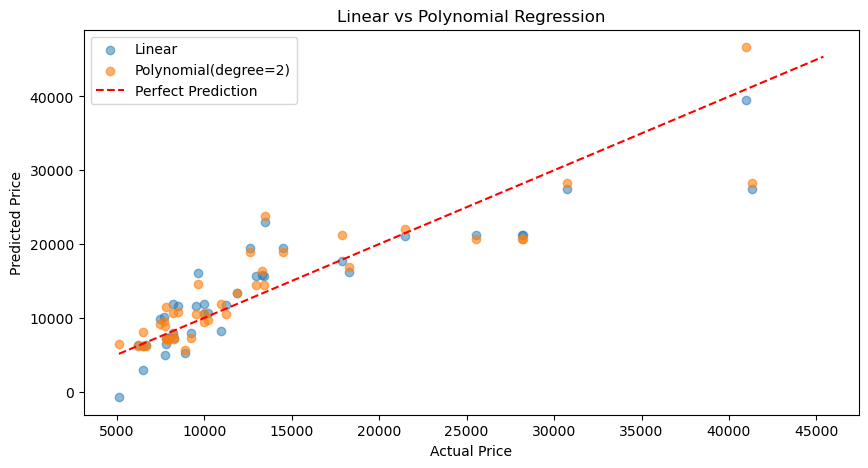

In [16]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_linear, label='Linear', alpha=0.5)
plt.scatter(y_test, y_pred_poly, label='Polynomial(degree=2)', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--' ,label='Perfect Prediction')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()